# Неделя 4. Понедельник

## Обучение без учителя


### Кластеризация

### Задание 1

Импортируйте несколько моделей кластеризации: 
* KMeans
* DBSCAN
* https://scikit-learn.org/stable/modules/clustering.html

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from umap import UMAP
import umap
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import sklearn
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

Импортируй датасет: `path = 'aux/X_train.txt'`

* В этом файле содержатся датчики мобильного телефона для различных активностей пользователя. Необходимо выявить какие кластеры можно выделить в данных и предположить, каким состояниями они соответствуют (пользователь в покое, идет, сидит и тд.)

* Фичей много, и здесь не особо нужно, что каждая из них значит, однако более детально об эксперименте можно прочитать [тут](https://data.world/uci/human-activity-recognition)

In [3]:
path = 'X_train.txt'
df = pd.read_csv(path, sep='\s+', header=None)


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\user\AppData\Local\Temp\ipykernel_17644\1546730472.py:2: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(path, sep='\s+', header=None)


In [4]:
df.shape

(7352, 561)

1. Примени ряд кластеризационных [моделей](https://scikit-learn.org/stable/modules/clustering.html) на импортированном датасете.

In [5]:
km = KMeans(n_clusters=2, random_state=42)
ap = AgglomerativeClustering(n_clusters=2)
dbs = DBSCAN(eps=1.8, min_samples=4)

km.fit(df)
ap.fit(df)
dbs.fit(df)

# метки можно потом достать так:
print(km.labels_[:10])
print(ap.labels_[:10])
print(dbs.labels_[:10])


[0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0]
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]


2. Определи и зафиксируй количество кластеров, которое наиболее оптимально с точки зрения метрики `silhouette`. Установи библиотеку [`yellowbrick`](https://www.scikit-yb.org/en/latest/api/cluster/silhouette.html) и визуализируй результаты для использованных методов (при использовании метода K-means). 

In [6]:
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer

In [7]:
k_range = range(2, 11)  
sil_scores = {}

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df)                  
    sil = silhouette_score(df, km.labels_)
    sil_scores[k] = sil

best_k = max(sil_scores, key=sil_scores.get)
print("Лучшее k по silhouette:", best_k, "score=", sil_scores[best_k])


Лучшее k по silhouette: 2 score= 0.48515412206804054


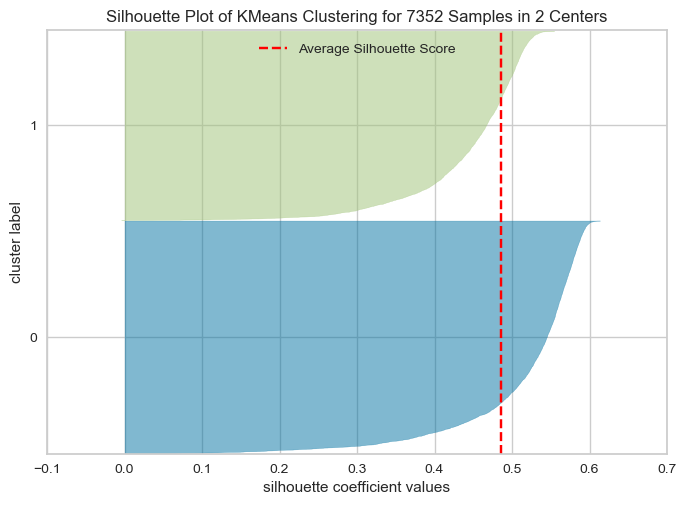

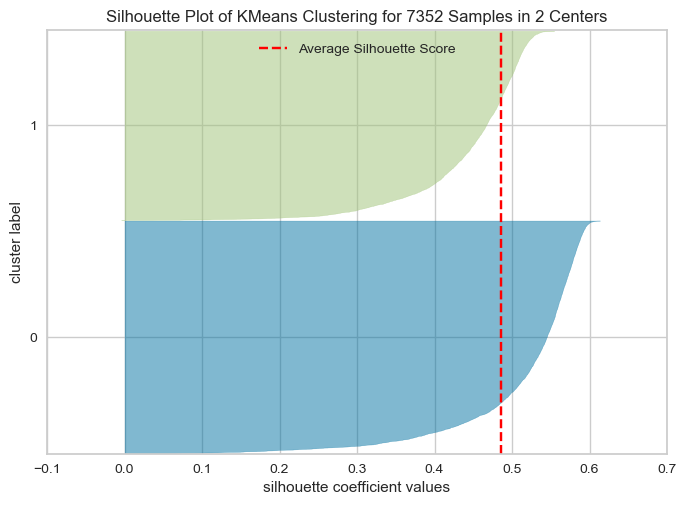

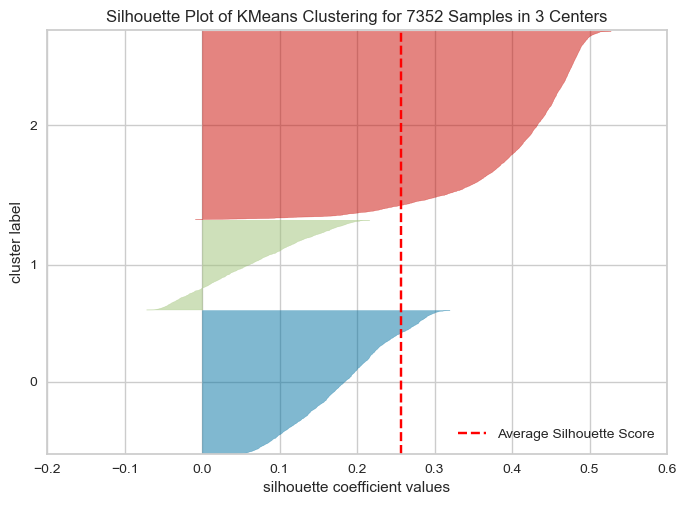

In [8]:
for k in [max(2, best_k-1), best_k, min(10, best_k+1)]:
    km = KMeans(n_clusters=k, random_state=42)
    viz = SilhouetteVisualizer(km, colors="yellowbrick")
    viz.fit(df)     
    viz.show()


k=2, silhouette=0.485
k=3, silhouette=0.257
k=4, silhouette=0.151
k=5, silhouette=0.124
k=6, silhouette=0.145
k=7, silhouette=0.128
k=8, silhouette=0.104
k=9, silhouette=0.112
k=10, silhouette=0.111


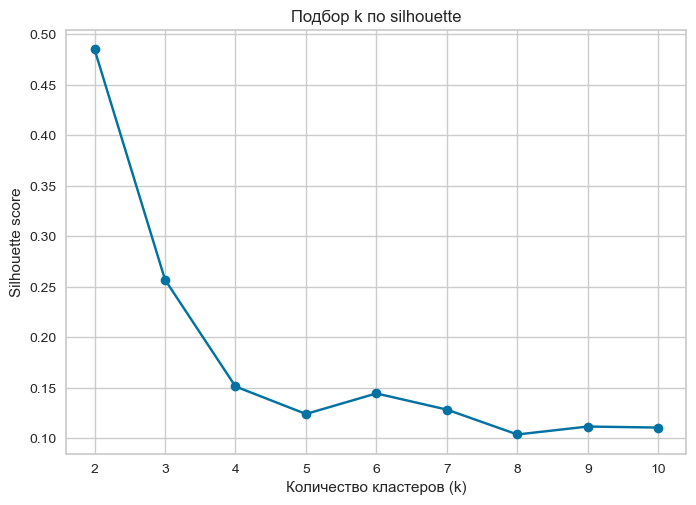

In [9]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []


for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df)  
    score = silhouette_score(df, km.labels_)
    scores.append(score)
    print(f"k={k}, silhouette={score:.3f}")

# график
plt.plot(range(2, 11), scores, marker="o")
plt.xlabel("Количество кластеров (k)")
plt.ylabel("Silhouette score")
plt.title("Подбор k по silhouette")
plt.show()


# ❓

Почему метрика `silhouette` может быть бессмысленной в некоторых случаях? Приведи пример такой ситуации. 

> ответ тут

4. Примените [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html), [UMAP](https://umap-learn.readthedocs.io/en/latest/) и [tSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) декомпозиции и визуализируйте полученные объекты в новом (двумерном или трехмерном) пространстве. В процессе перебирайте возможные параметры и сравнивайте результат по визуализациям.

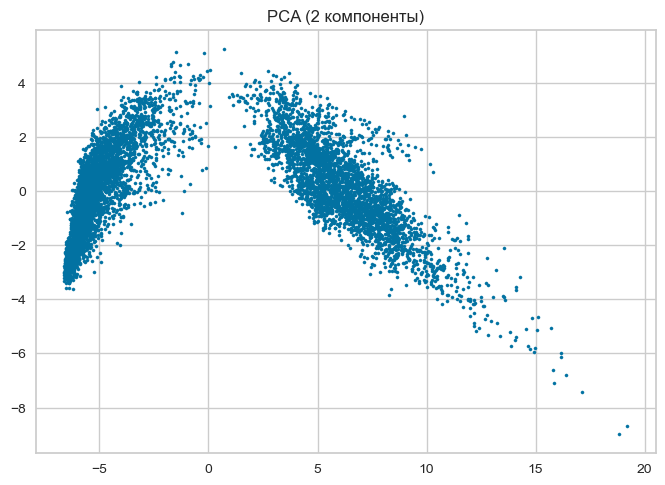

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# уменьшаем размерность до 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(df)

plt.scatter(X_pca[:,0], X_pca[:,1], s=5)
plt.title("PCA (2 компоненты)")
plt.show()


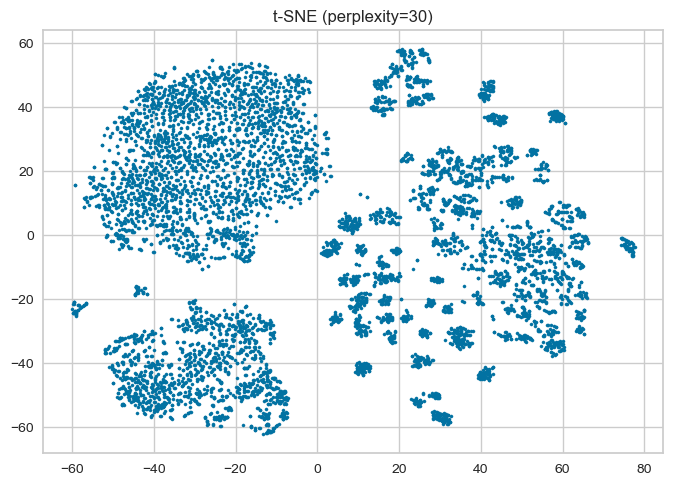

In [11]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=50, random_state=42)
X_tsne = tsne.fit_transform(df)

plt.scatter(X_tsne[:,0], X_tsne[:,1], s=5)
plt.title("t-SNE (perplexity=30)")
plt.show()


c:\Users\user\miniforge3\envs\eda_env\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



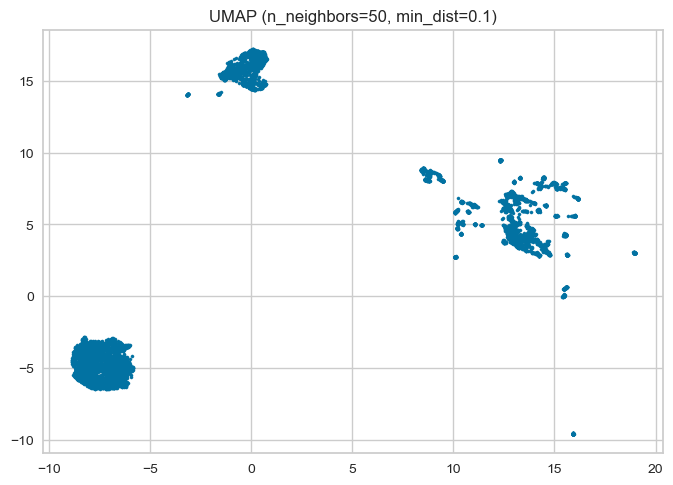

In [29]:
import umap

umap_model = umap.UMAP(n_components=2, n_neighbors=50, min_dist=0.01, random_state=42)
X_umap = umap_model.fit_transform(df)

plt.scatter(X_umap[:,0], X_umap[:,1], s=5)
plt.title("UMAP (n_neighbors=50, min_dist=0.1)")
plt.show()


In [13]:
import pandas as pd
import numpy as np


# --- опционально: цвет по кластерам (KMeans) ---
from sklearn.cluster import KMeans
USE_CLUSTER_COLOR = True
labels = None
if USE_CLUSTER_COLOR:
    km = KMeans(n_clusters=2, random_state=42)
    labels = km.fit_predict(df).astype(str)  # строки, чтобы легенда была аккуратной

# --- PCA (3D) ---
from sklearn.decomposition import PCA
pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(df)

# --- t-SNE (3D) ---
from sklearn.manifold import TSNE
# t-SNE может быть медленным на десятках тысяч строк → при необходимости можно сделать сэмпл
# df_tsne = df.sample(10000, random_state=42)  # раскомментируй при большом датасете
# labels_tsne = labels[df_tsne.index] if labels is not None else None
# X_tsne3 = TSNE(n_components=3, perplexity=30, learning_rate=200, init="pca", random_state=42).fit_transform(df_tsne)
X_tsne3 = TSNE(n_components=3, perplexity=30, learning_rate=200, init="pca", random_state=42).fit_transform(df)

# --- UMAP (3D) ---
import umap
umap3 = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap3 = umap3.fit_transform(df)

# --- интерактивные 3D графики Plotly ---
import plotly.express as px

def plot3d(X, title, color=None):
    fig = px.scatter_3d(
        x=X[:,0], y=X[:,1], z=X[:,2],
        color=color, opacity=0.7, title=title,
        width=850, height=600
    )
    fig.update_traces(marker=dict(size=3))
    fig.show()

plot3d(X_pca3,  "PCA (3 компоненты)",  color=labels if USE_CLUSTER_COLOR else None)
plot3d(X_tsne3, "t-SNE (3 компоненты)", color=labels if USE_CLUSTER_COLOR else None)
plot3d(X_umap3, "UMAP (3 компоненты)",  color=labels if USE_CLUSTER_COLOR else None)


c:\Users\user\miniforge3\envs\eda_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


5. Повтори шаги 1 и 2 для трансформированных данных. 

PCA: best k = 2 sil= 0.757


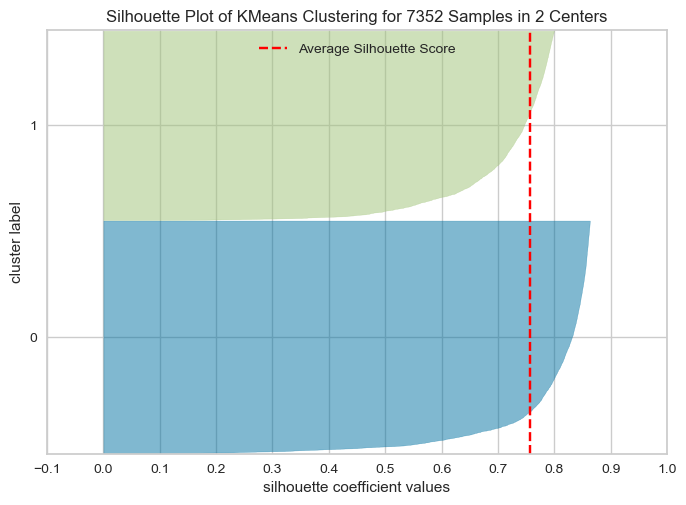

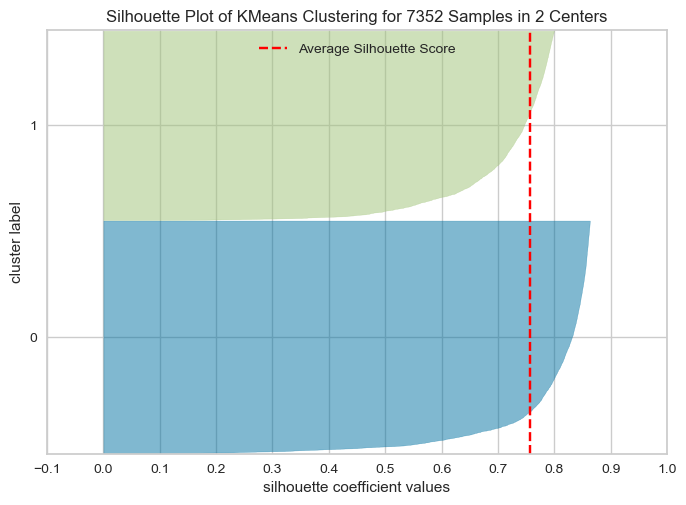

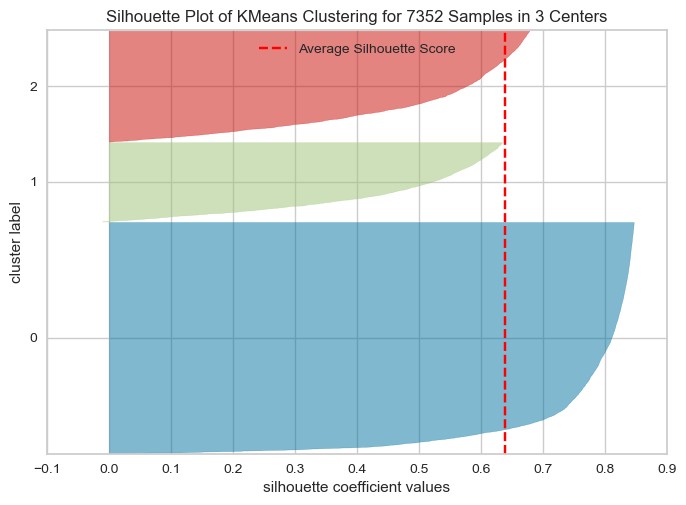

UMAP: best k = 3 sil= 0.729


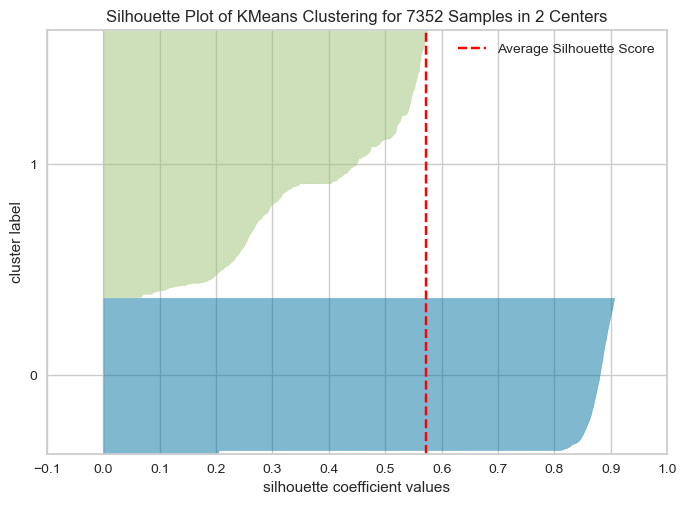

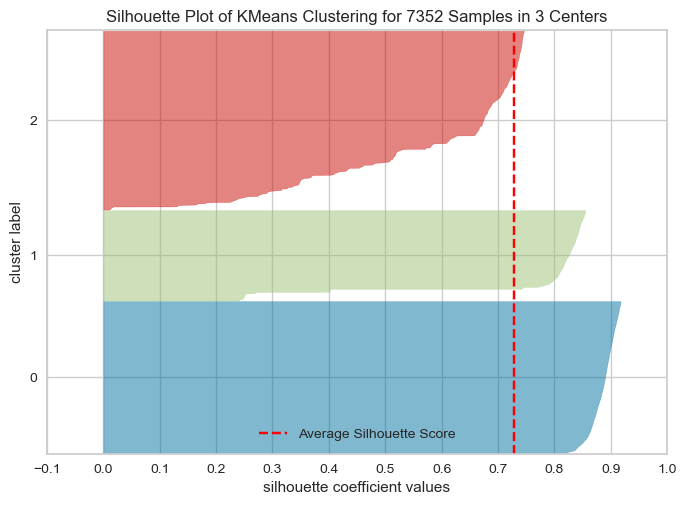

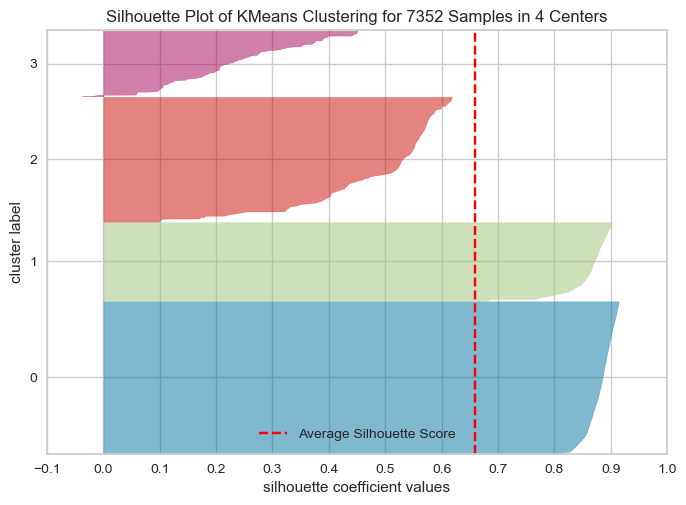

t-SNE: best k = 3 sil= 0.489


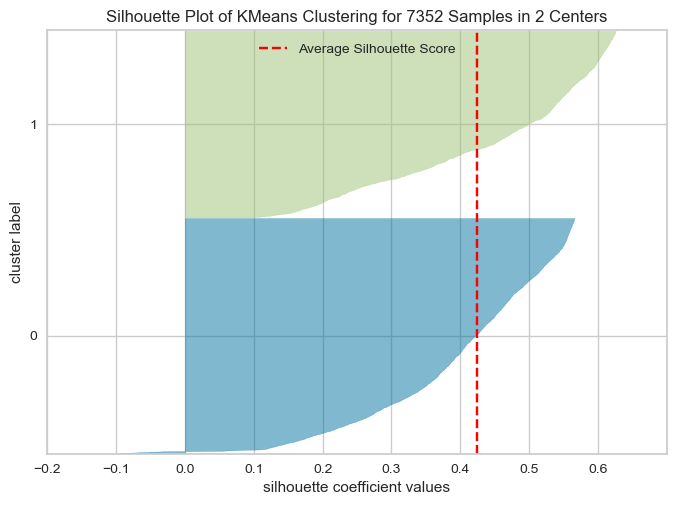

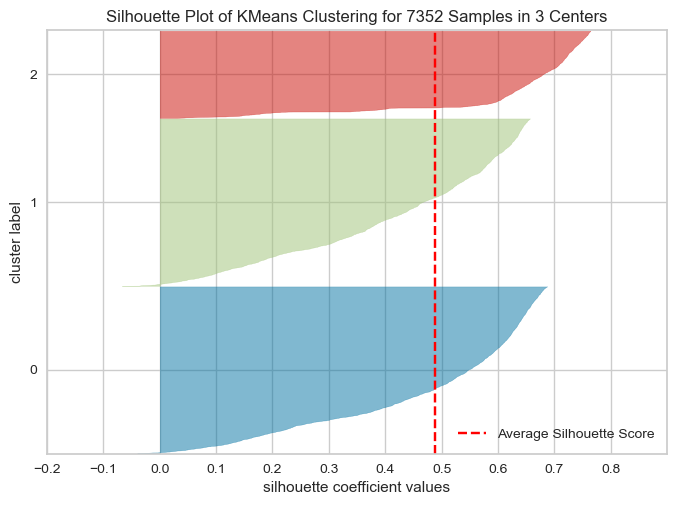

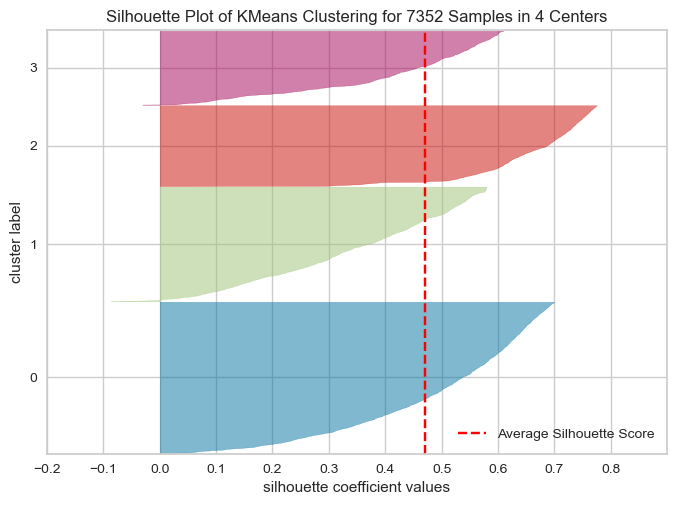

In [14]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer

def best_k_by_silhouette(X, k_range=range(2, 11)):
    scores = {}
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42)
        km.fit(X)
        scores[k] = silhouette_score(X, km.labels_)
    best_k = max(scores, key=scores.get)
    return best_k, scores

# --- 1) PCA (2D) ---
Xp = X_pca  # если 3D: Xp = X_pca[:, :2]
best_k_pca, scores_pca = best_k_by_silhouette(Xp)
print("PCA: best k =", best_k_pca, "sil=", round(scores_pca[best_k_pca], 3))

km_pca = KMeans(n_clusters=best_k_pca, random_state=42); km_pca.fit(Xp)
ap_pca = AgglomerativeClustering(n_clusters=best_k_pca); ap_pca.fit(Xp)
db_pca = DBSCAN(eps=1.8, min_samples=4);                db_pca.fit(Xp)

# визуализация силуэта (kmeans, около лучшего k)
for k in [max(2, best_k_pca-1), best_k_pca, min(10, best_k_pca+1)]:
    viz = SilhouetteVisualizer(KMeans(n_clusters=k, random_state=42), colors="yellowbrick")
    viz.fit(Xp); viz.show()

# --- 2) UMAP (2D) ---
Xu = X_umap  # если 3D: Xu = X_umap[:, :2]
best_k_umap, scores_umap = best_k_by_silhouette(Xu)
print("UMAP: best k =", best_k_umap, "sil=", round(scores_umap[best_k_umap], 3))

km_umap = KMeans(n_clusters=best_k_umap, random_state=42); km_umap.fit(Xu)
ap_umap = AgglomerativeClustering(n_clusters=best_k_umap); ap_umap.fit(Xu)
db_umap = DBSCAN(eps=1.8, min_samples=4);                db_umap.fit(Xu)

for k in [max(2, best_k_umap-1), best_k_umap, min(10, best_k_umap+1)]:
    viz = SilhouetteVisualizer(KMeans(n_clusters=k, random_state=42), colors="yellowbrick")
    viz.fit(Xu); viz.show()

# --- 3) t-SNE (2D) ---
Xt = X_tsne  # если 3D: Xt = X_tsne[:, :2]
best_k_tsne, scores_tsne = best_k_by_silhouette(Xt)
print("t-SNE: best k =", best_k_tsne, "sil=", round(scores_tsne[best_k_tsne], 3))

km_tsne = KMeans(n_clusters=best_k_tsne, random_state=42); km_tsne.fit(Xt)
ap_tsne = AgglomerativeClustering(n_clusters=best_k_tsne); ap_tsne.fit(Xt)
db_tsne = DBSCAN(eps=1.8, min_samples=4);                db_tsne.fit(Xt)

for k in [max(2, best_k_tsne-1), best_k_tsne, min(10, best_k_tsne+1)]:
    viz = SilhouetteVisualizer(KMeans(n_clusters=k, random_state=42), colors="yellowbrick")
    viz.fit(Xt); viz.show()


6. Сделай вывод: какой метод кластеризации и какие преобразования данных дают наилучший результат в контексте метрики силует. 

UMAP: best k = 3 sil= 0.729

7. Визуализируй наиболее успешный результат, цветос выдели кластеры

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ---- 1) посчитаем silhouette для каждой проекции (берём 2D: первые 2 столбца) ----
candidates = {}

# PCA
Xp = X_pca[:, :2] if X_pca.shape[1] > 2 else X_pca
best_k_p = None
best_s_p = -1
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42).fit(Xp)
    s  = silhouette_score(Xp, km.labels_)
    if s > best_s_p: best_s_p, best_k_p, best_km_p = s, k, km
candidates["PCA"] = {"X": Xp, "score": best_s_p, "k": best_k_p, "labels": best_km_p.labels_}

# UMAP
Xu = X_umap[:, :2] if X_umap.shape[1] > 2 else X_umap
best_k_u = None
best_s_u = -1
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42).fit(Xu)
    s  = silhouette_score(Xu, km.labels_)
    if s > best_s_u: best_s_u, best_k_u, best_km_u = s, k, km
candidates["UMAP"] = {"X": Xu, "score": best_s_u, "k": best_k_u, "labels": best_km_u.labels_}

# t-SNE
Xt = X_tsne[:, :2] if X_tsne.shape[1] > 2 else X_tsne
best_k_t = None
best_s_t = -1
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42).fit(Xt)
    s  = silhouette_score(Xt, km.labels_)
    if s > best_s_t: best_s_t, best_k_t, best_km_t = s, k, km
candidates["t-SNE"] = {"X": Xt, "score": best_s_t, "k": best_k_t, "labels": best_km_t.labels_}

# ---- 2) выбираем самый успешный результат ----
best_name = max(candidates, key=lambda k: candidates[k]["score"])
best = candidates[best_name]
print(f"Лучший: {best_name}, k={best['k']}, silhouette={best['score']:.3f}")

# ---- 3) визуализация (2D scatter, цветами выделяем кластеры) ----
fig = px.scatter(x=Xp[:,0], y=Xp[:,1],
                 color=labels.astype(str),  # строки → аккуратная легенда
                 title="PCA: KMeans k=2")
fig.update_traces(marker=dict(size=4, opacity=0.8))
fig.show()



Лучший: PCA, k=2, silhouette=0.757


Agglomerative: лучший k по silhouette = 4 | sil=0.502   
DBSCAN: лучший по silhouette  eps=0.200, min_samples=10, n_clusters=2, sil=0.486


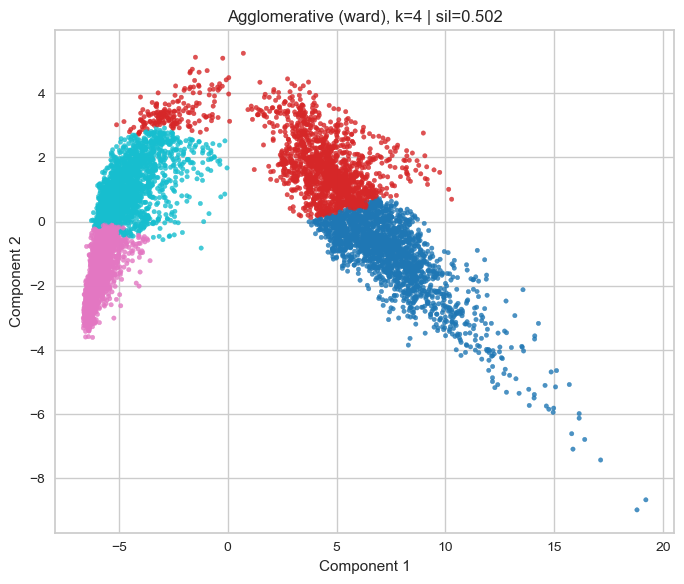

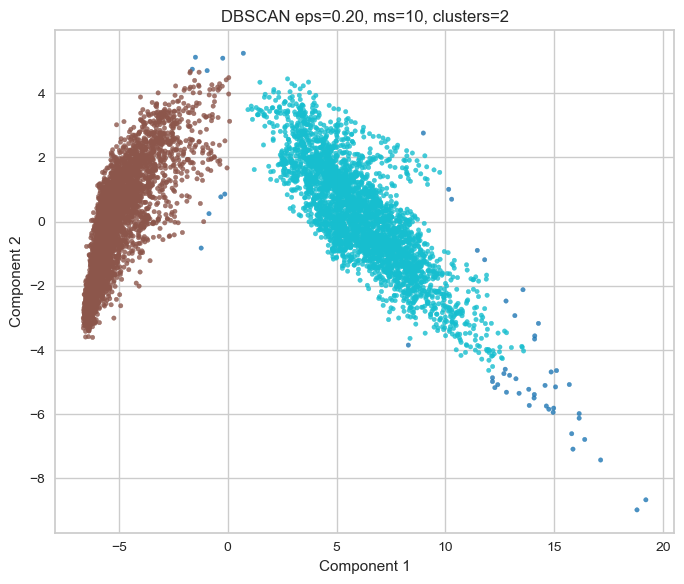

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score, v_measure_score
from sklearn.cluster import AgglomerativeClustering, DBSCAN

# ---- 0) ВЫБЕРИ ПРОСТРАНСТВО ДЛЯ РАБОТЫ ----
# Подставь то, что хочешь оценивать: X_pca, X_umap, X_tsne или df
# Если у тебя 3D, возьми первые 2 компоненты: X = X_pca[:, :2]
X = X_pca[:, :2]   # <-- при необходимости поменяй на X_umap[:, :2] или X_tsne[:, :2] или df.values

# стандартизация для корректных расстояний
Xs = StandardScaler().fit_transform(X)

# Если у тебя уже загружена разметка (y_true) из y_train.txt, оставь как есть.
# Если нет — поставь y_true = None.
try:
    y_true  # проверим, есть ли в окружении
except NameError:
    y_true = None

# ---- 1) Agglomerative: подбор k по silhouette (и внешние метрики, если есть y_true) ----
def eval_agglomerative(X, k_range=range(2, 13), linkage="ward"):
    rows = []
    for k in k_range:
        ap = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        labels = ap.fit_predict(X)
        sil = silhouette_score(X, labels)
        if y_true is not None:
            h = homogeneity_score(y_true, labels)
            c = completeness_score(y_true, labels)
            v = v_measure_score(y_true, labels)
        else:
            h = c = v = np.nan
        rows.append((k, sil, h, c, v))
    res = pd.DataFrame(rows, columns=["k","silhouette","homogeneity","completeness","v_measure"]).set_index("k")
    best_k = res["silhouette"].idxmax()
    return res, best_k

res_ap, best_k_ap = eval_agglomerative(Xs, k_range=range(2, 13), linkage="ward")
print("Agglomerative: лучший k по silhouette =", best_k_ap,
      f"| sil={res_ap.loc[best_k_ap,'silhouette']:.3f}",
      f"| H={res_ap.loc[best_k_ap,'homogeneity']:.3f}" if y_true is not None else "",
      f"| C={res_ap.loc[best_k_ap,'completeness']:.3f}" if y_true is not None else "",
      f"| V={res_ap.loc[best_k_ap,'v_measure']:.3f}" if y_true is not None else "")

# обучим финальную модель и возьмём метки
ap_best = AgglomerativeClustering(n_clusters=best_k_ap, linkage="ward").fit(Xs)
labels_ap = ap_best.labels_

# ---- 2) DBSCAN: подбор eps, min_samples по silhouette (и внешние метрики) ----
def eval_dbscan(X, eps_grid, min_samples_grid):
    rows = []
    for eps in eps_grid:
        for ms in min_samples_grid:
            db = DBSCAN(eps=eps, min_samples=ms)
            labels = db.fit_predict(X)
            # silhouette валиден, только если >=2 кластера и не все точки шум (-1)
            labs = set(labels)
            n_clusters = len([l for l in labs if l != -1])
            if n_clusters >= 2:
                sil = silhouette_score(X, labels)
            else:
                sil = np.nan
            if y_true is not None and n_clusters >= 1:
                h = homogeneity_score(y_true, labels)
                c = completeness_score(y_true, labels)
                v = v_measure_score(y_true, labels)
            else:
                h = c = v = np.nan
            rows.append((eps, ms, n_clusters, sil, h, c, v))
    res = pd.DataFrame(rows, columns=["eps","min_samples","n_clusters","silhouette","homogeneity","completeness","v_measure"])
    # выбираем по silhouette; если все NaN, возьмём по v_measure (если есть), иначе по max n_clusters
    if res["silhouette"].notna().any():
        best_idx = res["silhouette"].idxmax()
    elif y_true is not None and res["v_measure"].notna().any():
        best_idx = res["v_measure"].idxmax()
    else:
        best_idx = res["n_clusters"].idxmax()
    best = res.loc[best_idx]
    return res, best

# Сетки параметров (для стандартизованных 2D признаков адекватные диапазоны)
eps_grid = np.linspace(0.2, 2.0, 10)      # подстрой при необходимости
min_samples_grid = [3, 5, 10]

res_db, best_db = eval_dbscan(Xs, eps_grid, min_samples_grid)
def fmt(x, nd=3):
    return "nan" if pd.isna(x) else f"{x:.{nd}f}"

print(
    f"DBSCAN: лучший по silhouette  "
    f"eps={fmt(best_db.eps)}, min_samples={int(best_db.min_samples)}, "
    f"n_clusters={int(best_db.n_clusters)}, sil={fmt(best_db.silhouette)}"
)


# обучим DBSCAN с лучшими параметрами
db_best = DBSCAN(eps=best_db.eps, min_samples=int(best_db.min_samples)).fit(Xs)
labels_db = db_best.labels_

# ---- 3) Визуализация (2D) ----
def plot_clusters(X, labels, title):
    plt.figure(figsize=(7,6))
    plt.scatter(X[:,0], X[:,1], c=labels, s=10, alpha=0.8, cmap="tab10")
    plt.title(title); plt.xlabel("Component 1"); plt.ylabel("Component 2")
    plt.tight_layout(); plt.show()

plot_clusters(X, labels_ap, f"Agglomerative (ward), k={best_k_ap} | sil={res_ap.loc[best_k_ap,'silhouette']:.3f}")
plot_clusters(X, labels_db, f"DBSCAN eps={best_db.eps:.2f}, ms={int(best_db.min_samples)}, clusters={int(best_db.n_clusters)}")


8. Теперь настало время внешних метрик.

* Подгрузи файл `y_train.txt`. В нем разметка реальных активностей человека, [здесь](https://data.world/uci/human-activity-recognition) можно найти какой класс - какая активность.
* Посчитай внешние метрики $homogenity$ и $completeness$.
* Выбери оптимальное количество кластеров в контексте внешних метрик

In [19]:
path = 'y_train.txt'
y_true = pd.read_csv(path, sep='\s+', header=None)

<>:2: SyntaxWarning:

invalid escape sequence '\s'

<>:2: SyntaxWarning:

invalid escape sequence '\s'

C:\Users\user\AppData\Local\Temp\ipykernel_17644\160354734.py:2: SyntaxWarning:

invalid escape sequence '\s'



In [22]:
y_true
y_true = np.ravel(y_true)   # или: y_true = y_true.squeeze()

Agglomerative: лучший k по silhouette = 4 | sil=0.502 | H=0.388 | C=0.501 | V=0.437
DBSCAN: лучший по silhouette  eps=0.200, min_samples=10, n_clusters=2, sil=0.486


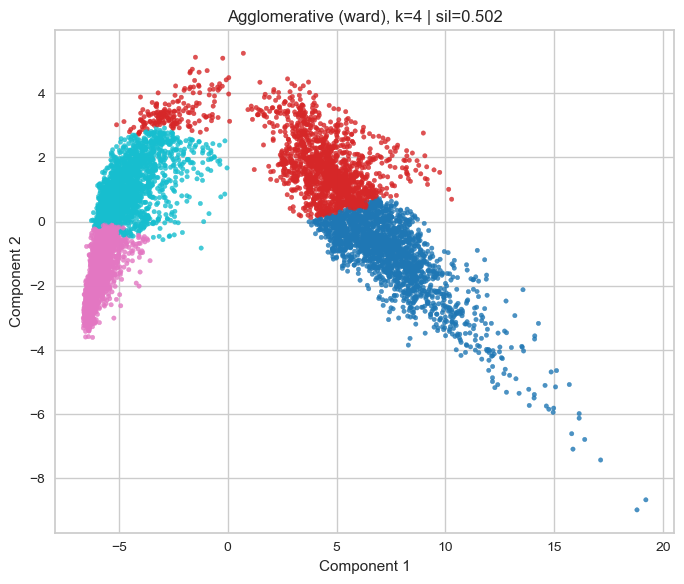

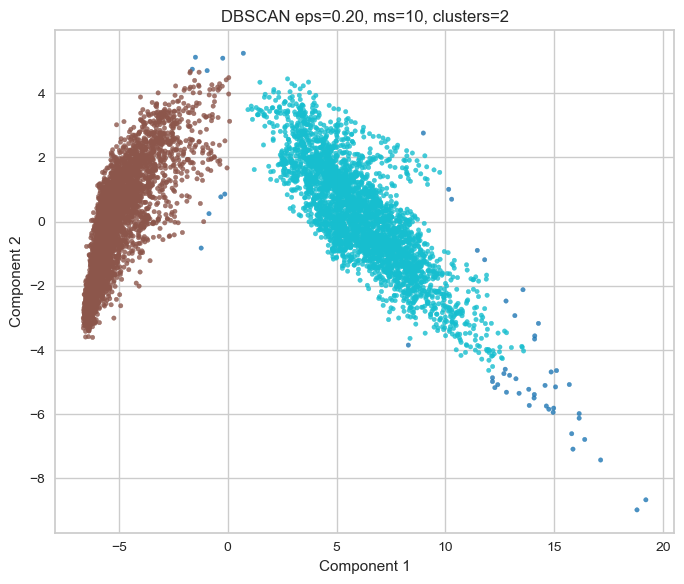

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score, v_measure_score
from sklearn.cluster import AgglomerativeClustering, DBSCAN

# ---- 0) ВЫБЕРИ ПРОСТРАНСТВО ДЛЯ РАБОТЫ ----
# Подставь то, что хочешь оценивать: X_pca, X_umap, X_tsne или df
# Если у тебя 3D, возьми первые 2 компоненты: X = X_pca[:, :2]
X = X_pca[:, :2]   # <-- при необходимости поменяй на X_umap[:, :2] или X_tsne[:, :2] или df.values

# стандартизация для корректных расстояний
Xs = StandardScaler().fit_transform(X)

# Если у тебя уже загружена разметка (y_true) из y_train.txt, оставь как есть.
# Если нет — поставь y_true = None.
try:
    y_true  # проверим, есть ли в окружении
except NameError:
    y_true = None

# ---- 1) Agglomerative: подбор k по silhouette (и внешние метрики, если есть y_true) ----
def eval_agglomerative(X, k_range=range(2, 13), linkage="ward"):
    rows = []
    for k in k_range:
        ap = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        labels = ap.fit_predict(X)
        sil = silhouette_score(X, labels)
        if y_true is not None:
            h = homogeneity_score(y_true, labels)
            c = completeness_score(y_true, labels)
            v = v_measure_score(y_true, labels)
        else:
            h = c = v = np.nan
        rows.append((k, sil, h, c, v))
    res = pd.DataFrame(rows, columns=["k","silhouette","homogeneity","completeness","v_measure"]).set_index("k")
    best_k = res["silhouette"].idxmax()
    return res, best_k

res_ap, best_k_ap = eval_agglomerative(Xs, k_range=range(2, 13), linkage="ward")
print("Agglomerative: лучший k по silhouette =", best_k_ap,
      f"| sil={res_ap.loc[best_k_ap,'silhouette']:.3f}",
      f"| H={res_ap.loc[best_k_ap,'homogeneity']:.3f}" if y_true is not None else "",
      f"| C={res_ap.loc[best_k_ap,'completeness']:.3f}" if y_true is not None else "",
      f"| V={res_ap.loc[best_k_ap,'v_measure']:.3f}" if y_true is not None else "")

# обучим финальную модель и возьмём метки
ap_best = AgglomerativeClustering(n_clusters=best_k_ap, linkage="ward").fit(Xs)
labels_ap = ap_best.labels_

# ---- 2) DBSCAN: подбор eps, min_samples по silhouette (и внешние метрики) ----
def eval_dbscan(X, eps_grid, min_samples_grid):
    rows = []
    for eps in eps_grid:
        for ms in min_samples_grid:
            db = DBSCAN(eps=eps, min_samples=ms)
            labels = db.fit_predict(X)
            # silhouette валиден, только если >=2 кластера и не все точки шум (-1)
            labs = set(labels)
            n_clusters = len([l for l in labs if l != -1])
            if n_clusters >= 2:
                sil = silhouette_score(X, labels)
            else:
                sil = np.nan
            if y_true is not None and n_clusters >= 1:
                h = homogeneity_score(y_true, labels)
                c = completeness_score(y_true, labels)
                v = v_measure_score(y_true, labels)
            else:
                h = c = v = np.nan
            rows.append((eps, ms, n_clusters, sil, h, c, v))
    res = pd.DataFrame(rows, columns=["eps","min_samples","n_clusters","silhouette","homogeneity","completeness","v_measure"])
    # выбираем по silhouette; если все NaN, возьмём по v_measure (если есть), иначе по max n_clusters
    if res["silhouette"].notna().any():
        best_idx = res["silhouette"].idxmax()
    elif y_true is not None and res["v_measure"].notna().any():
        best_idx = res["v_measure"].idxmax()
    else:
        best_idx = res["n_clusters"].idxmax()
    best = res.loc[best_idx]
    return res, best

# Сетки параметров (для стандартизованных 2D признаков адекватные диапазоны)
eps_grid = np.linspace(0.2, 2.0, 10)      # подстрой при необходимости
min_samples_grid = [3, 5, 10]

res_db, best_db = eval_dbscan(Xs, eps_grid, min_samples_grid)
def fmt(x, nd=3):
    return "nan" if pd.isna(x) else f"{x:.{nd}f}"

print(
    f"DBSCAN: лучший по silhouette  "
    f"eps={fmt(best_db.eps)}, min_samples={int(best_db.min_samples)}, "
    f"n_clusters={int(best_db.n_clusters)}, sil={fmt(best_db.silhouette)}"
)


# обучим DBSCAN с лучшими параметрами
db_best = DBSCAN(eps=best_db.eps, min_samples=int(best_db.min_samples)).fit(Xs)
labels_db = db_best.labels_

# ---- 3) Визуализация (2D) ----
def plot_clusters(X, labels, title):
    plt.figure(figsize=(7,6))
    plt.scatter(X[:,0], X[:,1], c=labels, s=10, alpha=0.8, cmap="tab10")
    plt.title(title); plt.xlabel("Component 1"); plt.ylabel("Component 2")
    plt.tight_layout(); plt.show()

plot_clusters(X, labels_ap, f"Agglomerative (ward), k={best_k_ap} | sil={res_ap.loc[best_k_ap,'silhouette']:.3f}")
plot_clusters(X, labels_db, f"DBSCAN eps={best_db.eps:.2f}, ms={int(best_db.min_samples)}, clusters={int(best_db.n_clusters)}")


<img src="https://icons.iconarchive.com/icons/icons8/windows-8/256/Programming-Github-icon.png" width=32 /> Пора закоммить изменения в файле. Сделай это с сообщением: 
`"Clustering: task 1 finished"`

После коммита выполни `!git status` в ячейке ниже. 

In [ ]:
# code 

### Задание 2

Скачай с kaggle [датасет](https://www.kaggle.com/arjunbhasin2013/ccdata) с информацией об обладателях кредитных карт. Кластеризируй объекты и проанализируй результат. 

In [ ]:
# code

<img src="https://icons.iconarchive.com/icons/icons8/windows-8/256/Programming-Github-icon.png" width=32 /> Сделай пуш на __github__. 